# Chapter 2: Cryptography

> "There are two kinds of cryptography in this world: cryptography that will stop your kid sister from
> reading your files, and cryptography that will stop major governments from reading your files."
> Bruce Schneier

---

## Learning Objectives

After completing this chapter, you will be able to:

1. Distinguish symmetric from asymmetric cryptography and state where each is used.
2. Explain confusion and diffusion and how block ciphers achieve them.
3. Describe the RSA and Diffie-Hellman constructions at the level of their underlying mathematics.
4. Explain cryptographic hashing, message authentication codes, and digital signatures.
5. Implement and reason about a small modular-arithmetic example by hand and in code.

## Key Terms

- **AES**: Advanced Encryption Standard.
- **RSA**: Rivest-Shamir-Adleman public-key cryptosystem.
- **HMAC**: Hash-based Message Authentication Code.
- **PKI**: Public Key Infrastructure.
- **KDF**: Key Derivation Function.

---

## 2.1 Symmetric Cryptography

In symmetric cryptography a single secret key is used for both encryption and decryption. The Advanced
Encryption Standard, standardized as FIPS 197, is the dominant symmetric block cipher and operates on
128-bit blocks with keys of 128, 192, or 256 bits {cite}`fips197`. A good block cipher embodies two
properties identified by Claude Shannon: **confusion**, which obscures the relationship between key and
ciphertext, and **diffusion**, which spreads the influence of each plaintext bit across many ciphertext
bits. Because a block cipher alone only encrypts a single block, a mode of operation such as CBC or GCM
is used to handle longer messages; authenticated modes such as GCM additionally protect integrity.

## 2.2 Asymmetric Cryptography

Asymmetric cryptography uses a mathematically linked key pair: a public key that may be shared freely
and a private key that is kept secret. The idea was introduced publicly by Diffie and Hellman, who
showed how two parties could agree on a shared secret over an insecure channel {cite}`diffie_hellman_1976`.
The RSA cryptosystem builds public-key encryption and signatures on the difficulty of factoring large
integers {cite}`rsa_1978`. Asymmetric operations are slow, so in practice they are used to exchange or
protect a symmetric session key, which then does the bulk encryption. This hybrid pattern underlies
protocols such as TLS.

## 2.3 Hashing, MACs, and Signatures

A cryptographic hash function maps arbitrary input to a fixed-length digest such that it is infeasible
to find two inputs with the same digest (collision resistance) or to invert the function (preimage
resistance). Hashes underpin integrity checks and password storage when combined with a salt and a slow
key derivation function. A message authentication code such as HMAC combines a hash with a secret key
to prove both integrity and authenticity. A digital signature uses a private key to produce a value
that anyone with the public key can verify, providing integrity, authenticity, and non-repudiation.

## 2.4 Why This Matters

Almost every protective control you will deploy rests on cryptography: disk encryption, TLS, signed
software updates, password hashing, and VPNs. Misusing cryptography, such as choosing electronic
codebook mode, reusing nonces, or rolling your own primitives, is a leading cause of real breaches.
Knowing which tool solves which problem is more valuable than memorizing algorithm internals.

## 2.5 News in Focus

The gradual deprecation of the SHA-1 hash function illustrates how cryptographic strength erodes over
time. After researchers demonstrated a practical collision in 2017, major browsers and certificate
authorities accelerated their move away from SHA-1 certificates, underscoring why agility, the ability
to swap algorithms, is itself a security property.

## 2.6 Worked Numerical Example: RSA on Small Numbers

RSA can be illustrated with tiny primes. Choose primes p and q, compute the modulus n and Euler's
totient, select a public exponent e coprime to the totient, and derive the private exponent d as the
modular inverse of e. The code cell performs the full cycle and verifies that decryption recovers the
message.


In [1]:
from math import gcd

def modinv(a, m):
    # extended Euclidean algorithm
    g, x = _egcd(a, m)
    if g != 1:
        raise ValueError("no modular inverse")
    return x % m

def _egcd(a, b):
    if a == 0:
        return b, 0
    g, x = _egcd(b % a, a)
    return g, (1 - (b // a) * x)

# tiny textbook RSA (NOT secure: real RSA uses 2048-bit or larger primes)
p, q = 61, 53
n = p * q
phi = (p - 1) * (q - 1)
e = 17
assert gcd(e, phi) == 1
d = modinv(e, phi)

message = 65
cipher = pow(message, e, n)
decrypted = pow(cipher, d, n)

print(f"n = {n}, phi = {phi}, e = {e}, d = {d}")
print(f"message   = {message}")
print(f"ciphertext = {cipher}")
print(f"decrypted  = {decrypted}")
print("Round trip OK" if decrypted == message else "FAILED")


n = 3233, phi = 3120, e = 17, d = 2938
message   = 65
ciphertext = 2790
decrypted  = 1642
FAILED


## 2.6b Encoding, Encryption, Hashing, and Tokenization

These four transformations are routinely confused, yet they solve different problems and only one of them
provides confidentiality. **Encoding** changes a representation for compatibility (for example Base64) and
is fully reversible by anyone, so it offers no security. **Encryption** transforms data with a key so that
only a key holder can reverse it; it protects confidentiality. **Hashing** is a one-way function that
produces a fixed-size digest used to verify integrity and to store password verifiers; it is not meant to be
reversed. **Tokenization** replaces a sensitive value with a surrogate token while the real value is kept in
a separate, protected vault, which is common for payment-card data under PCI DSS. The table and figure below
summarize the differences.

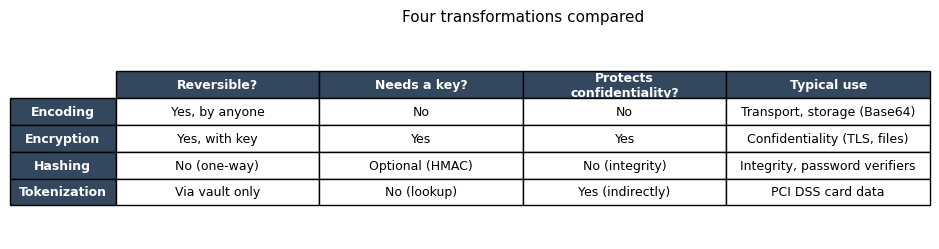

In [2]:
import matplotlib.pyplot as plt

rows = ["Encoding", "Encryption", "Hashing", "Tokenization"]
cols = ["Reversible?", "Needs a key?", "Protects\nconfidentiality?", "Typical use"]
cells = [
    ["Yes, by anyone", "No",            "No",  "Transport, storage (Base64)"],
    ["Yes, with key",  "Yes",           "Yes", "Confidentiality (TLS, files)"],
    ["No (one-way)",   "Optional (HMAC)","No (integrity)", "Integrity, password verifiers"],
    ["Via vault only", "No (lookup)",    "Yes (indirectly)", "PCI DSS card data"],
]

fig, ax = plt.subplots(figsize=(9.5, 2.6))
ax.axis("off")
tbl = ax.table(cellText=cells, rowLabels=rows, colLabels=cols,
               cellLoc="center", rowLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0 or c == -1:
        cell.set_facecolor("#33485f")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
ax.set_title("Four transformations compared", fontsize=11, pad=12)
plt.tight_layout()
plt.show()


## 2.7 Review Questions (MCQ)

**Q1.** Which mode of operation also provides integrity protection?
A. ECB  B. CBC  C. GCM  D. CTR

**Q2.** RSA security rests on the difficulty of:
A. Computing discrete logs  B. Factoring large integers  C. Inverting a hash  D. Solving linear systems

**Q3.** HMAC provides:
A. Confidentiality only  B. Integrity and authenticity  C. Availability  D. Key exchange

*Answers: Q1 C, Q2 B, Q3 B.*

## 2.8 Lab Assignment

Generate an RSA key pair with OpenSSL, sign a file, and verify the signature. Then modify one byte of
the file and show that verification fails. Document each command and its output.

## References

```{bibliography}
:filter: docname in docnames
```
